In [198]:
import numpy as np
import scipy.fft
from PIL import Image

In [199]:
target_size = 500

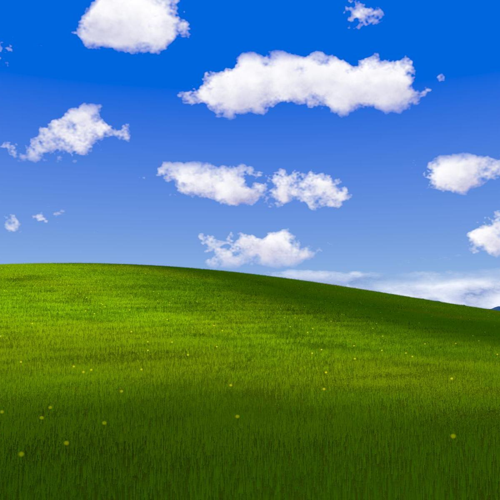

In [200]:
bliss = Image.open("data/bliss.jpg")
bliss = bliss.resize((int(target_size / bliss.height * bliss.width), target_size))
margin = (bliss.width - target_size) / 2
bliss = bliss.crop((margin, 0, bliss.width - margin, bliss.height))
bliss

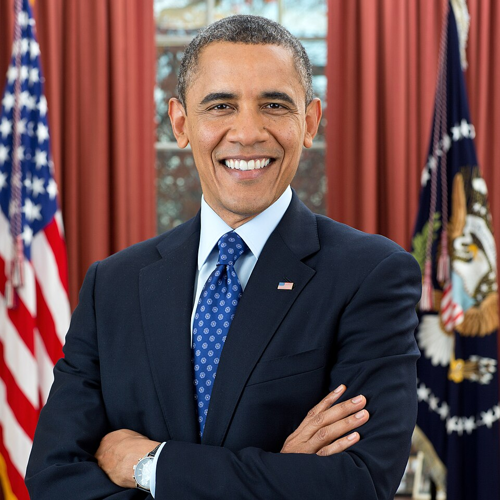

In [201]:
obama = Image.open("data/obama.jpg")
obama = obama.resize((target_size, int(target_size * obama.height / obama.width)))
obama = obama.crop((0, 0, obama.width, target_size))
obama

In [202]:
def blend_fourier(a: np.ndarray, b: np.ndarray, window: int) -> np.ndarray:
    a_fft = scipy.fft.fft2(a)
    a_fft = scipy.fft.fftshift(a_fft)
    b_fft = scipy.fft.fft2(b)
    b_fft = scipy.fft.fftshift(b_fft)

    blend_fft = b_fft.copy()

    start = target_size // 2 - window // 2
    end = target_size // 2 + window // 2
    mask = np.zeros_like(a_fft, dtype=bool)
    mask[start:end, start:end] = True  # TODO: non-square windows

    blend_fft[mask] = a_fft[mask]

    raw = np.abs(np.fft.ifft2(np.fft.ifftshift(blend_fft)))
    return raw / (1 + raw)

In [203]:
def make_frame(window: int):
    b = np.asarray(bliss) / 255.0
    a = np.asarray(obama) / 255.0
    blend = np.stack(
        (
            blend_fourier(a=a[:, :, 0], b=b[:, :, 0], window=window),
            blend_fourier(a=a[:, :, 1], b=b[:, :, 1], window=window),
            blend_fourier(a=a[:, :, 2], b=b[:, :, 2], window=window),
        ),
        axis=-1,
    )
    blend *= 255.0
    blend = blend.astype(np.uint8)
    return Image.fromarray(blend), blend

In [ ]:
# vec3 reinhard_extended_luminance(vec3 v, float max_white_l)
# {
#     float l_old = luminance(v);
#     float numerator = l_old * (1.0f + (l_old / (max_white_l * max_white_l)));
#     float l_new = numerator / (1.0f + l_old);
#     return change_luminance(v, l_new);
# }

SyntaxError: invalid decimal literal (2675122681.py, line 4)

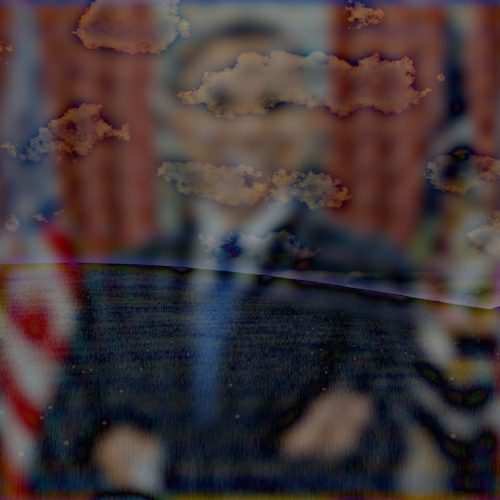

In [212]:
make_frame(30)[0]

In [205]:
import cv2 as cv

cv.imwrite("test.jpg", make_frame(300)[1][:, :, [2, 1, 0]])

True

In [206]:
from tqdm import tqdm

fourcc = cv.VideoWriter.fourcc(*"DIVX")
out = cv.VideoWriter("output.avi", fourcc, 30.0, (target_size, target_size))
try:
    for window in tqdm(np.geomspace(2, 500, 300, dtype=int)):
        out.write(make_frame(window)[1][:, :, [2, 1, 0]])
finally:
    out.release()

100%|██████████| 300/300 [00:08<00:00, 34.76it/s]
